# Memory-Safer Time-Series Classification

This notebook is split so the large pickle files are processed one at a time.

Recommended run order:
1. Setup
2. Helper functions
3. Build KOI label map
4. Process `C_00_LC_DATA.pkl`
5. Process `villanova-kepler-binaries-lcs.pkl`
6. Process `koi_cumulative_lcs.pkl`
7. Combine processed datasets
8. Train LSTM classifier
9. Evaluate

The original crash was most likely caused by trying to hold multiple multi-GB pickle datasets in memory at once. This version avoids that.


In [10]:
from pathlib import Path
from typing import Optional, List, Tuple
import gc
import pickle
import sys
import types
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import subprocess

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

warnings.filterwarnings("ignore")

BASE_DIR = Path("jr-test") if Path("jr-test").exists() else Path(".")
ARTIFACT_DIR = BASE_DIR / "artifacts"
ARTIFACT_DIR.mkdir(exist_ok=True)

SEQ_LEN = 256
BATCH_SIZE = 32
EPOCHS = 15
LR = 1e-3
HIDDEN_SIZE = 64
NUM_LAYERS = 2
DROPOUT = 0.2
RANDOM_STATE = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

KOI_LABEL_MAP_PATH = ARTIFACT_DIR / "koi_label_map.csv"
COMBINED_X_PATH = ARTIFACT_DIR / "combined_X.npy"
COMBINED_Y_PATH = ARTIFACT_DIR / "combined_y.npy"
COMBINED_META_PATH = ARTIFACT_DIR / "combined_metadata.csv"
CLASSES_PATH = ARTIFACT_DIR / "combined_classes.npy"
MODEL_PATH = ARTIFACT_DIR / "lstm_time_series_classifier.pt"
PREDICTIONS_PATH = ARTIFACT_DIR / "test_predictions.csv"

print(f"Base directory: {BASE_DIR.resolve()}")
print(f"Artifact directory: {ARTIFACT_DIR.resolve()}")
print(f"Device: {DEVICE}")


Base directory: /Users/jithinrajan/Desktop/Spring'26/CS567/fault-in-our-stars/jr-test
Artifact directory: /Users/jithinrajan/Desktop/Spring'26/CS567/fault-in-our-stars/jr-test/artifacts
Device: cpu


In [11]:
PROCESS_SCRIPT = BASE_DIR / "process_dataset_artifact.py"
SUBPROCESS_PYTHON = Path("/Users/jithinrajan/miniconda3/bin/python")
if not SUBPROCESS_PYTHON.exists():
    SUBPROCESS_PYTHON = Path(sys.executable)


def run_processing_subprocess(dataset_name: str) -> None:
    cmd = [str(SUBPROCESS_PYTHON), str(PROCESS_SCRIPT), "--dataset", dataset_name]
    print("Running:", " ".join(cmd))
    result = subprocess.run(
        cmd,
        cwd=str(BASE_DIR.parent if BASE_DIR.name == "jr-test" else BASE_DIR),
        capture_output=True,
        text=True,
    )
    if result.stdout:
        print(result.stdout)
    if result.stderr:
        print(result.stderr)
    if result.returncode != 0:
        raise RuntimeError(f"Processing subprocess failed for {dataset_name} with exit code {result.returncode}")


def ensure_numpy_pickle_compat() -> None:
    aliases = {
        "numpy._core": "numpy.core",
        "numpy._core.numeric": "numpy.core.numeric",
        "numpy._core.multiarray": "numpy.core.multiarray",
        "numpy._core.umath": "numpy.core.umath",
        "numpy._core._multiarray_umath": "numpy.core._multiarray_umath",
    }
    for old_name, new_name in aliases.items():
        if old_name not in sys.modules:
            sys.modules[old_name] = __import__(new_name, fromlist=["*"])


class _LegacyStringArrayCompat:
    def __init__(self) -> None:
        self.data = None

    def __setstate__(self, state) -> None:
        if isinstance(state, tuple) and len(state) == 2:
            self.data = np.asarray(state[1], dtype=object)
        else:
            self.data = np.asarray(state, dtype=object)

    def __len__(self) -> int:
        return len(self.data)

    def __iter__(self):
        return iter(self.data)

    def __array__(self, dtype=None):
        return np.asarray(self.data, dtype=dtype)

    @property
    def dtype(self):
        return object


class _CompatUnpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if (module, name) == ("pandas._libs.arrays", "__pyx_unpickle_NDArrayBacked"):
            def custom(cls, checksum, state):
                return _LegacyStringArrayCompat()

            return custom
        return super().find_class(module, name)


def read_pickle_compat(path: Path) -> pd.DataFrame:
    ensure_numpy_pickle_compat()
    try:
        df = pd.read_pickle(path)
    except NotImplementedError as exc:
        if "NDArrayBacked" not in str(exc) and "StringDtype" not in str(exc) and "array([" not in str(exc):
            raise
        with open(path, "rb") as fh:
            df = _CompatUnpickler(fh).load()
    if not isinstance(df, pd.DataFrame):
        raise TypeError(f"Expected DataFrame in {path}, got {type(df)}")
    return df


def normalize_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    if "KIC" not in df.columns and df.index.name == "KIC":
        df = df.reset_index()
    if "# ID" not in df.columns and df.index.name == "# ID":
        df = df.reset_index()
    return df


def infer_id_column(df: pd.DataFrame) -> str:
    for col in ["KIC", "kepid", "# ID", "id"]:
        if col in df.columns:
            return col
    raise KeyError(f"No ID column found in columns: {list(df.columns)}")


def infer_flux_column(df: pd.DataFrame) -> str:
    for col in ["detflux", "flux", "PDCSAP_FLUX"]:
        if col in df.columns:
            return col
    raise KeyError(f"No flux column found in columns: {list(df.columns)}")


def infer_label_column(df: pd.DataFrame) -> str:
    for col in ["Class", "class", "label", "Label"]:
        if col in df.columns:
            return col
    raise KeyError(f"No label column found in columns: {list(df.columns)}")


def to_float_array(values) -> np.ndarray:
    arr = np.asarray(values, dtype=np.float32).reshape(-1)
    return arr[np.isfinite(arr)]


def resample_sequence(values: np.ndarray, fixed_len: int = SEQ_LEN) -> np.ndarray:
    values = to_float_array(values)
    if len(values) == 0:
        return np.zeros(fixed_len, dtype=np.float32)
    if len(values) == 1:
        return np.repeat(values, fixed_len).astype(np.float32)

    x_old = np.linspace(0.0, 1.0, len(values), dtype=np.float32)
    x_new = np.linspace(0.0, 1.0, fixed_len, dtype=np.float32)
    seq = np.interp(x_new, x_old, values).astype(np.float32)

    mean = float(seq.mean())
    std = float(seq.std())
    if std < 1e-6:
        return (seq - mean).astype(np.float32)
    return ((seq - mean) / std).astype(np.float32)


def build_sequence(group: pd.DataFrame, flux_col: str) -> np.ndarray:
    if "quarter" in group.columns:
        group = group.sort_values("quarter")

    parts = []
    for _, row in group.iterrows():
        arr = to_float_array(row[flux_col])
        if len(arr) > 0:
            parts.append(arr)

    if not parts:
        return np.zeros(SEQ_LEN, dtype=np.float32)

    return resample_sequence(np.concatenate(parts), fixed_len=SEQ_LEN)


def read_koi_catalog_labels(csv_path: Path) -> pd.Series:
    catalog = pd.read_csv(csv_path, comment="#")
    catalog["kepid"] = pd.to_numeric(catalog["kepid"], errors="coerce").astype("Int64")
    catalog["koi_disposition"] = catalog["koi_disposition"].astype(str).str.strip().str.upper()
    catalog = catalog.dropna(subset=["kepid", "koi_disposition"])

    priority = ["CONFIRMED", "CANDIDATE", "FALSE POSITIVE"]

    def collapse(group: pd.Series) -> Optional[str]:
        values = set(group.tolist())
        for label in priority:
            if label in values:
                return label
        return None

    label_map = catalog.groupby("kepid")["koi_disposition"].apply(collapse).dropna()
    label_map.index = label_map.index.astype(int)
    return label_map


def dataset_artifact_paths(dataset_name: str) -> Tuple[Path, Path]:
    return ARTIFACT_DIR / f"{dataset_name}_X.npy", ARTIFACT_DIR / f"{dataset_name}_meta.csv"


def process_and_save_dataset(pickle_path: Path, dataset_name: str, koi_label_map: Optional[pd.Series] = None) -> Tuple[Path, Path]:
    print(f"Loading {pickle_path.name} ...")
    df = normalize_dataframe(read_pickle_compat(pickle_path))
    id_col = infer_id_column(df)
    flux_col = infer_flux_column(df)
    label_col = infer_label_column(df) if dataset_name == "c00" else None

    keep_cols = [id_col, flux_col]
    if "quarter" in df.columns:
        keep_cols.append("quarter")
    if label_col is not None:
        keep_cols.append(label_col)
    df = df[keep_cols].copy()

    df[id_col] = pd.to_numeric(df[id_col], errors="coerce")
    df = df.dropna(subset=[id_col]).copy()
    df[id_col] = df[id_col].astype(int)

    sequences = []
    records = []

    grouped = df.groupby(id_col, sort=False)
    total_groups = grouped.ngroups
    print(f"Groups to process: {total_groups}")

    for idx, (object_id, group) in enumerate(grouped, start=1):
        if dataset_name == "villanova":
            label = "binary"
        elif dataset_name == "koi":
            if koi_label_map is None or object_id not in koi_label_map.index:
                continue
            label = str(koi_label_map.loc[object_id]).strip().upper()
        elif dataset_name == "c00":
            label = str(group[label_col].iloc[0]).strip()
        else:
            raise ValueError(f"Unsupported dataset name: {dataset_name}")

        if label == "" or label.lower() == "nan":
            continue

        sequences.append(build_sequence(group, flux_col))
        records.append({"dataset": dataset_name, "object_id": object_id, "label": label})

        if idx % 2000 == 0:
            print(f"Processed {idx}/{total_groups} groups")

    if not sequences:
        raise RuntimeError(f"No sequences generated from {pickle_path}")

    X = np.stack(sequences).astype(np.float32)
    meta = pd.DataFrame(records)
    x_path, meta_path = dataset_artifact_paths(dataset_name)
    np.save(x_path, X)
    meta.to_csv(meta_path, index=False)

    print(f"Saved {dataset_name} sequences: {x_path}")
    print(f"Saved {dataset_name} metadata: {meta_path}")
    print(f"Shape: {X.shape}")
    print(meta['label'].value_counts())

    del df, grouped, sequences, records, X, meta
    gc.collect()
    return x_path, meta_path


class IndexedSequenceDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray, indices: np.ndarray):
        self.X = X
        self.y = y
        self.indices = np.asarray(indices)

    def __len__(self) -> int:
        return len(self.indices)

    def __getitem__(self, idx: int):
        real_idx = int(self.indices[idx])
        x = np.asarray(self.X[real_idx], dtype=np.float32)
        y = int(self.y[real_idx])
        return torch.from_numpy(x).unsqueeze(-1), torch.tensor(y, dtype=torch.long)


class LSTMClassifier(nn.Module):
    def __init__(self, input_size: int, hidden_size: int, num_layers: int, num_classes: int, dropout: float):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.head = nn.Sequential(
            nn.Linear(hidden_size * 2, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        output, _ = self.lstm(x)
        pooled = output.mean(dim=1)
        return self.head(pooled)


def build_loaders_from_indices(X: np.ndarray, y: np.ndarray, train_idx: np.ndarray, test_idx: np.ndarray):
    train_ds = IndexedSequenceDataset(X, y, train_idx)
    test_ds = IndexedSequenceDataset(X, y, test_idx)
    return (
        DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True),
        DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False),
    )


def train_model(model: nn.Module, train_loader: DataLoader, y_train: np.ndarray) -> List[float]:
    class_counts = np.bincount(y_train)
    class_weights = len(y_train) / (len(class_counts) * np.maximum(class_counts, 1))
    criterion = nn.CrossEntropyLoss(weight=torch.tensor(class_weights, dtype=torch.float32, device=DEVICE))
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)

    model.to(DEVICE)
    history = []
    for epoch in range(EPOCHS):
        model.train()
        total_loss = 0.0
        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / max(len(train_loader), 1)
        history.append(avg_loss)
        print(f"Epoch {epoch + 1:02d}/{EPOCHS} - loss={avg_loss:.4f}")

    return history


def predict(model: nn.Module, loader: DataLoader) -> Tuple[np.ndarray, np.ndarray]:
    model.eval()
    y_true = []
    y_pred = []
    with torch.no_grad():
        for xb, yb in loader:
            logits = model(xb.to(DEVICE))
            y_true.extend(yb.numpy().tolist())
            y_pred.extend(torch.argmax(logits, dim=1).cpu().numpy().tolist())
    return np.asarray(y_true), np.asarray(y_pred)


In [12]:
# Build KOI labels once.

koi_label_map = read_koi_catalog_labels(BASE_DIR / "cumulative_koi.csv")
koi_label_df = koi_label_map.rename("label").reset_index().rename(columns={"kepid": "KIC"})
koi_label_df.to_csv(KOI_LABEL_MAP_PATH, index=False)
print(f"Saved KOI label map: {KOI_LABEL_MAP_PATH}")
print(koi_label_df['label'].value_counts())
koi_label_df.head()


Saved KOI label map: artifacts/koi_label_map.csv
FALSE POSITIVE    4603
CONFIRMED         1973
CANDIDATE         1638
Name: label, dtype: int64


,KIC,label
0,757450,CONFIRMED
1,892772,FALSE POSITIVE
2,1025986,CANDIDATE
3,1026032,FALSE POSITIVE
4,1026957,CONFIRMED


In [13]:
# Process the smaller C_00 dataset in a subprocess so kernel crashes during unpickling do not kill the notebook.

run_processing_subprocess("c00")


Running: /Users/jithinrajan/miniconda3/bin/python process_dataset_artifact.py --dataset c00
Loading /Users/jithinrajan/Desktop/Spring'26/CS567/fault-in-our-stars/jr-test/C_00_LC_DATA.pkl ...
Groups to process: 7748
Processed 2000/7748 groups
Processed 4000/7748 groups
Processed 6000/7748 groups
Saved sequences: /Users/jithinrajan/Desktop/Spring'26/CS567/fault-in-our-stars/jr-test/artifacts/c00_X.npy
Saved metadata: /Users/jithinrajan/Desktop/Spring'26/CS567/fault-in-our-stars/jr-test/artifacts/c00_meta.csv
Final shape: (7748, 256)
label
Noise     4476
OTHPER    2548
DSCUT      263
GDOR       161
EA         149
EB         143
RRab         8
Name: count, dtype: int64



In [14]:
# Process the Villanova binaries dataset in a subprocess.
# Run this alone and wait for it to finish before moving on.

run_processing_subprocess("villanova")


Running: /Users/jithinrajan/miniconda3/bin/python process_dataset_artifact.py --dataset villanova
Loading /Users/jithinrajan/Desktop/Spring'26/CS567/fault-in-our-stars/jr-test/villanova-kepler-binaries-lcs.pkl ...
Groups to process: 2907
Processed 2000/2907 groups
Saved sequences: /Users/jithinrajan/Desktop/Spring'26/CS567/fault-in-our-stars/jr-test/artifacts/villanova_X.npy
Saved metadata: /Users/jithinrajan/Desktop/Spring'26/CS567/fault-in-our-stars/jr-test/artifacts/villanova_meta.csv
Final shape: (2907, 256)
label
binary    2907
Name: count, dtype: int64



In [15]:
# Process the KOI dataset in a subprocess.
# Run this alone and wait for it to finish before moving on.

run_processing_subprocess("koi")


Running: /Users/jithinrajan/miniconda3/bin/python process_dataset_artifact.py --dataset koi
Loading /Users/jithinrajan/Desktop/Spring'26/CS567/fault-in-our-stars/jr-test/koi_cumulative_lcs.pkl ...
Groups to process: 8214
Processed 2000/8214 groups
Processed 4000/8214 groups
Processed 6000/8214 groups
Processed 8000/8214 groups
Saved sequences: /Users/jithinrajan/Desktop/Spring'26/CS567/fault-in-our-stars/jr-test/artifacts/koi_X.npy
Saved metadata: /Users/jithinrajan/Desktop/Spring'26/CS567/fault-in-our-stars/jr-test/artifacts/koi_meta.csv
Final shape: (8214, 256)
label
FALSE POSITIVE    4603
CONFIRMED         1973
CANDIDATE         1638
Name: count, dtype: int64



In [16]:
# Combine the already-processed dataset artifacts.

dataset_names = ["c00", "villanova", "koi"]
x_parts = []
meta_parts = []

for dataset_name in dataset_names:
    x_path, meta_path = dataset_artifact_paths(dataset_name)
    if not x_path.exists() or not meta_path.exists():
        raise FileNotFoundError(f"Missing processed artifact for {dataset_name}: {x_path} / {meta_path}")

    x_part = np.load(x_path, mmap_mode="r")
    meta_part = pd.read_csv(meta_path)
    x_parts.append(np.asarray(x_part, dtype=np.float32))
    meta_parts.append(meta_part)
    print(f"{dataset_name:10s} -> {x_part.shape}")

X = np.concatenate(x_parts, axis=0).astype(np.float32)
meta = pd.concat(meta_parts, ignore_index=True)

label_counts = meta["label"].value_counts().sort_values(ascending=False)
rare_labels = label_counts[label_counts < 2].index.tolist()
if rare_labels:
    keep_mask = ~meta["label"].isin(rare_labels)
    X = X[keep_mask.to_numpy()]
    meta = meta.loc[keep_mask].reset_index(drop=True)
    print("Dropped classes with fewer than 2 samples:")
    print(rare_labels)

classes = sorted(meta["label"].unique().tolist())
label_to_id = {label: idx for idx, label in enumerate(classes)}
y = meta["label"].map(label_to_id).to_numpy(dtype=np.int64)

np.save(COMBINED_X_PATH, X)
np.save(COMBINED_Y_PATH, y)
np.save(CLASSES_PATH, np.array(classes, dtype=object))
meta.to_csv(COMBINED_META_PATH, index=False)

print(f"Saved combined X: {COMBINED_X_PATH}")
print(f"Saved combined y: {COMBINED_Y_PATH}")
print(f"Saved classes: {CLASSES_PATH}")
print(f"Saved metadata: {COMBINED_META_PATH}")
print(f"Final shape: {X.shape}")
print(meta['label'].value_counts())

del X, y, meta, x_parts, meta_parts
gc.collect()


c00        -> (7748, 256)
villanova  -> (2907, 256)
koi        -> (8214, 256)
Saved combined X: artifacts/combined_X.npy
Saved combined y: artifacts/combined_y.npy
Saved classes: artifacts/combined_classes.npy
Saved metadata: artifacts/combined_metadata.csv
Final shape: (18869, 256)
FALSE POSITIVE    4603
Noise             4476
binary            2907
OTHPER            2548
CONFIRMED         1973
CANDIDATE         1638
DSCUT              263
GDOR               161
EA                 149
EB                 143
RRab                 8
Name: label, dtype: int64


500

Epoch 01/15 - loss=2.0819
Epoch 02/15 - loss=1.7998
Epoch 03/15 - loss=1.7400
Epoch 04/15 - loss=1.6938
Epoch 05/15 - loss=1.6295
Epoch 06/15 - loss=1.5950
Epoch 07/15 - loss=1.5882
Epoch 08/15 - loss=1.5554
Epoch 09/15 - loss=1.5350
Epoch 10/15 - loss=1.5123
Epoch 11/15 - loss=1.4939
Epoch 12/15 - loss=1.4546
Epoch 13/15 - loss=1.4181
Epoch 14/15 - loss=1.3858
Epoch 15/15 - loss=1.3444


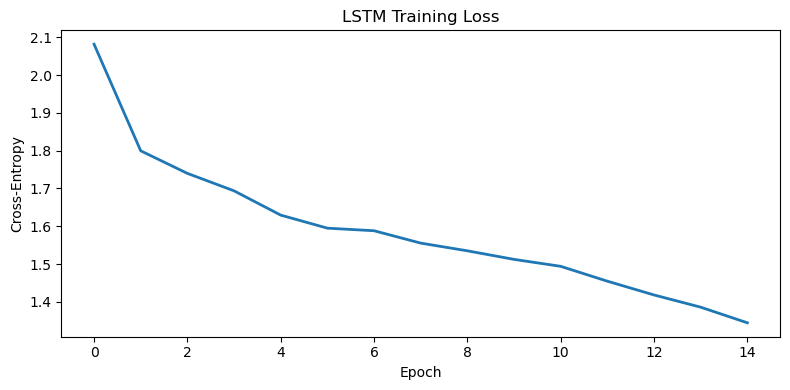

Saved model: artifacts/lstm_time_series_classifier.pt
Train size: 15095
Test size: 3774


In [17]:
# Train the LSTM classifier using memory-mapped arrays.

if not COMBINED_X_PATH.exists() or not COMBINED_Y_PATH.exists() or not CLASSES_PATH.exists():
    raise FileNotFoundError("Run the combine block first.")

X = np.load(COMBINED_X_PATH, mmap_mode="r")
y = np.load(COMBINED_Y_PATH, mmap_mode="r")
classes = np.load(CLASSES_PATH, allow_pickle=True).tolist()

indices = np.arange(len(y))
stratify_y = np.asarray(y) if pd.Series(np.asarray(y)).value_counts().min() >= 2 else None
train_idx, test_idx = train_test_split(
    indices,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=stratify_y,
)

train_loader, test_loader = build_loaders_from_indices(X, y, train_idx, test_idx)
model = LSTMClassifier(
    input_size=1,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    num_classes=len(classes),
    dropout=DROPOUT,
)

history = train_model(model, train_loader, np.asarray(y)[train_idx])

checkpoint = {
    "state_dict": model.state_dict(),
    "classes": classes,
    "train_idx": train_idx,
    "test_idx": test_idx,
    "history": history,
    "sequence_length": SEQ_LEN,
    "hidden_size": HIDDEN_SIZE,
    "num_layers": NUM_LAYERS,
    "dropout": DROPOUT,
}
torch.save(checkpoint, MODEL_PATH)

plt.figure(figsize=(8, 4))
plt.plot(history, linewidth=2)
plt.title("LSTM Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy")
plt.tight_layout()
plt.show()

print(f"Saved model: {MODEL_PATH}")
print(f"Train size: {len(train_idx)}")
print(f"Test size: {len(test_idx)}")


Accuracy: 0.5291
Balanced accuracy: 0.4592

Classification report:
                precision    recall  f1-score   support

     CANDIDATE       0.19      0.20      0.20       328
     CONFIRMED       0.25      0.02      0.03       395
         DSCUT       0.08      0.32      0.13        53
            EA       0.25      0.20      0.22        30
            EB       0.11      0.82      0.19        28
FALSE POSITIVE       0.55      0.68      0.61       921
          GDOR       0.09      0.03      0.05        32
         Noise       0.70      0.75      0.73       895
        OTHPER       0.60      0.30      0.40       510
          RRab       0.01      1.00      0.02         1
        binary       0.85      0.73      0.78       581

      accuracy                           0.53      3774
     macro avg       0.34      0.46      0.31      3774
  weighted avg       0.56      0.53      0.52      3774



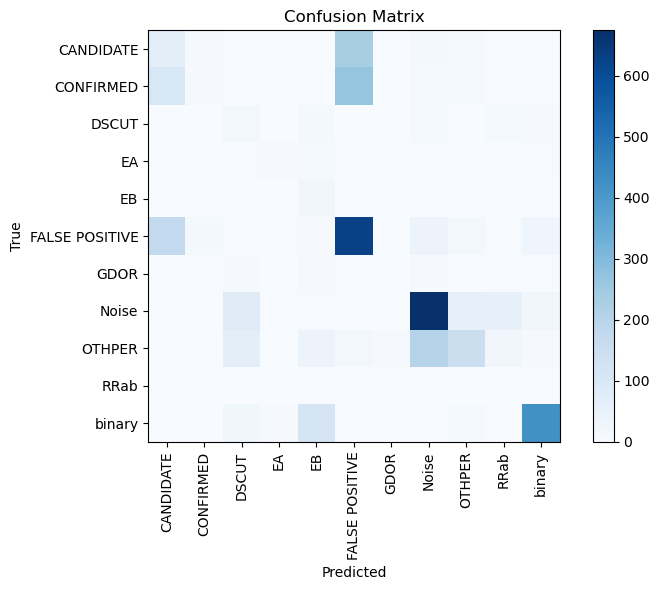

Saved predictions: artifacts/test_predictions.csv


,dataset,object_id,label,true_label,pred_label
0,koi,9116510,CANDIDATE,CANDIDATE,FALSE POSITIVE
1,c00,202088072,Noise,Noise,Noise
2,koi,10383696,FALSE POSITIVE,FALSE POSITIVE,FALSE POSITIVE
3,villanova,4073730,binary,binary,binary
4,c00,202066133,OTHPER,OTHPER,DSCUT


In [18]:
# Evaluate on the saved test split.

if not MODEL_PATH.exists():
    raise FileNotFoundError("Run the training block first.")

X = np.load(COMBINED_X_PATH, mmap_mode="r")
y = np.load(COMBINED_Y_PATH, mmap_mode="r")
meta = pd.read_csv(COMBINED_META_PATH)
checkpoint = torch.load(MODEL_PATH, map_location=DEVICE)

classes = checkpoint["classes"]
test_idx = np.asarray(checkpoint["test_idx"])
id_to_label = {idx: label for idx, label in enumerate(classes)}

model = LSTMClassifier(
    input_size=1,
    hidden_size=checkpoint["hidden_size"],
    num_layers=checkpoint["num_layers"],
    num_classes=len(classes),
    dropout=checkpoint["dropout"],
)
model.load_state_dict(checkpoint["state_dict"])
model.to(DEVICE)

test_ds = IndexedSequenceDataset(X, y, test_idx)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)
y_true, y_pred = predict(model, test_loader)

meta_test = meta.iloc[test_idx].reset_index(drop=True)
meta_test["true_label"] = [id_to_label[idx] for idx in y_true]
meta_test["pred_label"] = [id_to_label[idx] for idx in y_pred]
meta_test.to_csv(PREDICTIONS_PATH, index=False)

target_names = [id_to_label[idx] for idx in range(len(classes))]
print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
print(f"Balanced accuracy: {balanced_accuracy_score(y_true, y_pred):.4f}")
print("\nClassification report:")
print(classification_report(y_true, y_pred, target_names=target_names, zero_division=0))

cm = confusion_matrix(y_true, y_pred, labels=list(range(len(classes))))
plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(range(len(classes)), target_names, rotation=90)
plt.yticks(range(len(classes)), target_names)
plt.colorbar()
plt.tight_layout()
plt.show()

print(f"Saved predictions: {PREDICTIONS_PATH}")
meta_test.head()
